# LSTM Model

## Objective

This notebook develops a Long Short-Term Memory (LSTM) neural network for forecasting weekly German electricity demand.

The data are scaled and transformed into sequential observations suitable for deep learning. Model performance is evaluated using RMSE, MAE and MAPE and compared with the benchmark, SARIMA, SARIMAX and feature-based forecasting models.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

## Load Dataset

The weekly electricity demand dataset is loaded and prepared for LSTM modelling.

In [2]:
weekly_load = pd.read_csv(
    "weekly_load.csv",
    index_col=0,
    parse_dates=True
)

weekly_load.head()

,load
timestamp,
2015-01-04 00:00:00+00:00,47233.739583
2015-01-11 00:00:00+00:00,56191.101190
2015-01-18 00:00:00+00:00,57672.678571
2015-01-25 00:00:00+00:00,58613.303571
2015-02-01 00:00:00+00:00,58734.029762


## Forecast Evaluation Function

A reusable evaluation function is defined to calculate RMSE, MAE and MAPE for evaluating forecast accuracy.

In [3]:
def evaluate_forecast(actual, forecast):

    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mae = mean_absolute_error(actual, forecast)
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

## Train-Test Split

The dataset is divided into training and testing subsets using the final 104 observations as the forecasting horizon.

In [4]:
forecast_horizon = 104

train = weekly_load.iloc[:-forecast_horizon]

test = weekly_load.iloc[-forecast_horizon:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 197
Testing observations: 104


## Data Scaling

The electricity demand values are scaled to the range [0,1] using Min-Max scaling to improve neural network training stability.

In [5]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train[["load"]])

test_scaled = scaler.transform(test[["load"]])

## Sequence Generation

Input sequences are created from the scaled time series to enable the LSTM model to learn temporal dependencies.

In [6]:
look_back = 12

def create_sequences(data, look_back):

    X, y = [], []

    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back])

    return np.array(X), np.array(y)

In [7]:
X_train, y_train = create_sequences(
    train_scaled,
    look_back
)

combined = np.concatenate(
    [train_scaled[-look_back:], test_scaled]
)

X_test, y_test = create_sequences(
    combined,
    look_back
)

In [8]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

## LSTM Model Architecture

A single-layer Long Short-Term Memory (LSTM) neural network is constructed for forecasting weekly electricity demand. The network learns temporal dependencies from historical observations and predicts future demand values.

In [9]:
# Build LSTM model

model = Sequential()

model.add(
    LSTM(
        64,
        activation="tanh",
        input_shape=(look_back, 1)
    )
)

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

The LSTM model is trained using the training sequences. The training loss is monitored over multiple epochs to assess model convergence.

In [10]:
# Train LSTM model

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.1383 - val_loss: 0.0049
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0547 - val_loss: 0.0052
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0421 - val_loss: 0.0099
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0374 - val_loss: 0.0046
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0357 - val_loss: 0.0046
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0349 - val_loss: 0.0048
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0341 - val_loss: 0.0045
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0347 - val_loss: 0.0045
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0335 - val_loss: 0.0045
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0333 - val_loss: 0.0046
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0327 - val_loss: 0.0045
Epoch 12/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

## Training Loss

The training and validation loss curves are plotted to evaluate the learning behaviour of the LSTM model during training.

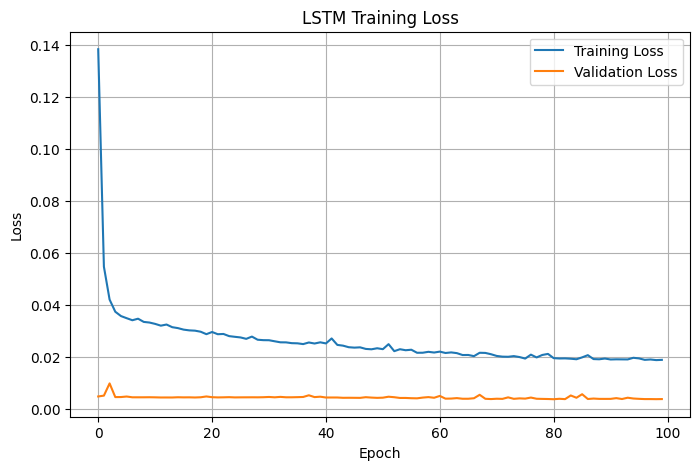

In [11]:
# Plot training history

plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.savefig(
    "lstm_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()